In [2]:
from __future__ import annotations
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%matplotlib inline

# figure/ 에서 실행하든 repo root 에서 실행하든 동작하도록 경로 해석
CWD = Path.cwd()
FIGURE_DIR = CWD if (CWD / "figutils").exists() else CWD / "figure"
REPO_ROOT = FIGURE_DIR.parent
for _p in (str(REPO_ROOT), str(FIGURE_DIR)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Helvetica 폰트 (있으면 적용) — 다른 figure 노트북과 동일
font_path = FIGURE_DIR / "figutils" / "Helvetica.ttf"
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# umap.ipynb · auc_scatter.ipynb · gen_performance.ipynb 와 동일한 chapter 팔레트 remap
COLOR_REMAP = {
    "#98df8a": "#91c987",  # I. Infectious Diseases
    "#ff7f0e": "#ec713f",  # II. Neoplasms
    "#ff9896": "#dd5752",  # III. Blood & Immune Disorders
    "#2ca02c": "#4f7951",  # IV. Metabolic Diseases
    "#9edae5": "#90c0c2",  # V. Mental Disorders
    "#7f7f7f": "#87776a",  # VI/VII. Nervous / Eye Diseases
    "#dbdb8d": "#e6c186",  # VIII. Ear Diseases
    "#d62728": "#c34a54",  # IX. Circulatory Diseases
    "#17becf": "#567797",  # X. Respiratory Diseases
    "#8c564b": "#6b512a",  # XI. Digestive Diseases
    "#1f77b4": "#2964b8",  # XIII. Musculoskeletal Diseases
    "#ffbb78": "#f7b141",  # XIV. Genitourinary Diseases
    "#e377c2": "#e45c88",  # XV/XVII. Pregnancy / Congenital
    "#FFFF00": "#E7C547",  # Diabetes Drugs
    "#000a35": "#1d1f20",  # Death
}

In [8]:
# === 설정 ============================================================
# 학습된 체크포인트 (최신 = out/0506/ckpt.pt). 필요시 후보를 추가/수정.
CKPT_CANDIDATES = [
    REPO_ROOT / "out" / "0506" / "ckpt.pt",
    REPO_ROOT / "out" / "ckpt.pt",
]
DATA_DIR = REPO_ROOT.parent / "data"
LABELS_CHAPTER_PATH = DATA_DIR / "labels_chapter.csv"

# 입력(history)=kr_val(2002-2010), 정답(future)=kr_test(2011-2013)
HISTORY_BIN = DATA_DIR / "kr_val.bin"
FUTURE_BIN = DATA_DIR / "kr_test.bin"

# 실행 파라미터
N_PATIENTS = 5000   # 평가 환자 수 (작게=빠른 스모크, None 이면 overlap 전체)
BLOCK_SIZE = 512    # context window
EVAL_YEARS = 3.0    # 관측 기간 (2011-2013)
MIN_CASES = 25      # 토큰 평가 최소 발생 수
N_BINS = 10         # reliability 분위(bin) 수

SAVE_FIGS = True
OUTPUT_DIR = REPO_ROOT / "figure" / "out"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _first_existing(paths, what):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError(f"{what} 를 찾지 못함. 후보:\n  " + "\n  ".join(str(p) for p in paths))


CKPT_PATH = _first_existing(CKPT_CANDIDATES, "checkpoint")
print("checkpoint :", CKPT_PATH)
print("history    :", HISTORY_BIN)
print("future     :", FUTURE_BIN)
print("output     :", OUTPUT_DIR)

checkpoint : /home/hsh/hsh/GPT-Disease-Drug-Prediction/out/0506/ckpt.pt
history    : /home/hsh/hsh/data/kr_val.bin
future     : /home/hsh/hsh/data/kr_test.bin
output     : /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out


In [4]:
# === 모델 로드 + 데이터 로드 ==========================================
import importlib
import torch
from figutils.common import load_model, load_composite_data
import figutils.calibration as calibration_module

calibration_module = importlib.reload(calibration_module)
CalibrationAnalyzer = calibration_module.CalibrationAnalyzer

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model, _ckpt = load_model(CKPT_PATH, device=DEVICE)

# 체크포인트의 token-shift 설정을 그대로 사용해야 라벨/색이 토큰과 정렬됨
APPLY_TOKEN_SHIFT = bool(getattr(getattr(model, "config", None), "apply_token_shift", False))
print("apply_token_shift =", APPLY_TOKEN_SHIFT)

hist_raw, _, hist_p2i = load_composite_data(HISTORY_BIN)
fut_raw, _, fut_p2i = load_composite_data(FUTURE_BIN)

# Figure 3g 는 자체적으로 cal_grid(=val/test 겹치는 환자 전체, min_cases 완화)를 만들어 쓴다.
# analyzer.results -> chapter/color/n_cases 테이블 헬퍼만 여기서 정의.


def token_meta_table(analyzer):
    rows = []
    for tid, info in analyzer.results.items():
        col = info.get("color", "#999999")
        rows.append({
            "token": tid,
            "name": info["name"],
            "chapter": info.get("chapter", "") or "Unknown",
            "color": COLOR_REMAP.get(col, col),  # gen_performance 와 동일 팔레트
            "n_cases": info["n_cases"],
            "auc": info["auc"],
        })
    return pd.DataFrame(rows).set_index("token").sort_values("n_cases", ascending=False)


[INFO] Loading model from /home/hsh/hsh/GPT-Disease-Drug-Prediction/out/0506/ckpt.pt → cuda
[INFO] Detected BinaryChangeHead → using model_v2
[OK]  Model loaded (36.90M params)
apply_token_shift = False
[INFO] Loading data from /home/hsh/hsh/data/kr_val.bin
[OK]  3,726,301 events, 23,850 patients
[INFO] Loading data from /home/hsh/hsh/data/kr_test.bin
[OK]  8,587,093 events, 93,715 patients


## Helpers

reliability(신뢰도) 곡선 계산 함수 — 예측확률을 분위(quantile) bin 으로 나눠 bin 별 (평균 예측확률, 평균 관측빈도, 표본수)를 반환. Figure 3g 가 이 함수를 사용한다.

In [5]:
def reliability_curve(pred, obs, n_bins=10, strategy="quantile"):
    # bin 별 (평균 예측확률, 평균 관측빈도, 표본수)
    pred = np.asarray(pred, dtype=float)
    obs = np.asarray(obs, dtype=float)
    if strategy == "quantile":
        edges = np.quantile(pred, np.linspace(0, 1, n_bins + 1))
    else:
        edges = np.linspace(pred.min(), pred.max(), n_bins + 1)
    edges = np.unique(edges).astype(float)
    if edges.size < 2:
        edges = np.array([float(pred.min()), float(pred.max()) + 1e-12])
    edges[-1] += 1e-12
    mp, mo, cnt = [], [], []
    for i in range(len(edges) - 1):
        m = (pred >= edges[i]) & (pred < edges[i + 1])
        if m.sum() == 0:
            continue
        mp.append(pred[m].mean())
        mo.append(obs[m].mean())
        cnt.append(int(m.sum()))
    return np.array(mp), np.array(mo), np.array(cnt)


### Per-Disease Calibration by ICD Chapter (Delphi Fig. 3b style)

각 ICD chapter 소패널에 **해당 chapter의 개별 disease token을 한 선**으로 그린다(선 굵기/투명도 = 발생 수 비례). 축은 log-log의 approximate rate `[1/yr]`이며, 3년 누적발생확률을 일정 hazard로 가정해 `-log(1 - p) / EVAL_YEARS`로 환산한다. 논문(Delphi Extended Data Fig. 3b)과 같은 2×8 chapter grid 배치.

**보정 방식(중요):** 이 뷰의 miscalibration은 (1) 질환 선 내부의 **기울기**가 대각선보다 완만하고(모델 rate spread가 관측보다 넓음), (2) 질환마다 **레벨 offset**이 있는 두 가지다. 상수배(단일 scale)로는 눈에 안 띈다. 따라서 held-out `fit` 절반에서
1. 전역 log-log 선형 기울기 `b1`(`log10 obs ~ b0 + b1·log10 model`, bin 표본수 가중)을 적합해 기울기를 교정하고,
2. 질환별 잔차 **레벨 offset**(교정된 rate와 관측 rate의 로그평균 비)을 추가로 적합한다.

`eval` 절반에는 `calibrated_rate = offset_d · 10^{b0 + b1·log10(model_rate)}` 를 적용한다(누수 방지). 이렇게 하면 각 질환 곡선이 대각선을 따라 정렬되어 논문 그림처럼 되고, before와 확연히 달라진다. (Platt은 확률을 좁은 구간으로 압축해 log-log에서 세로 밴드로 뭉치므로 이 뷰에는 부적합 — 확률 스케일 reliability는 Figure 3b2/3f 참고.)

**축 범위:** 각 decile bin이 약 `n_eval/10 ≈ 1,000`명이라 최소 관측빈도가 `1/1000` → 관측 rate 바닥이 `≈ 3e-4/yr`이고, 여기에 점들이 쌓여 패널 아래쪽에 **수평으로 뚝 끊기는 띠**가 생긴다. 이를 숨기기 위해 축 하한을 그 위(`GRID_RATE_XLIM`/`GRID_RATE_YLIM`, 기본 `1e-3`)로 올린다. 보정 후 model rate가 대부분 `1e-3` 이상이라 데이터 손실은 거의 없고, x·y를 같은 범위로 두어 대각선을 45°로 유지한다.

**질환 밀도:** 이 그림 전용으로 `GRID_MIN_CASES`를 낮추고 `GRID_N_PATIENTS=None`(val/test 겹치는 환자 전체)로 재평가해 더 많은 disease token을 포함한다(노트북의 `cal`=5000·min_cases=25는 그대로 둠).

> Delphi Fig. 3b는 longitudinal instantaneous rate를 age-sex stratum decile로 평가하고 코호트가 수십만~수백만이라 chapter당 선이 더 많고 `10^-5~10^-6/yr`까지 관측된다. 이 그림은 3년 horizon 근사치라 관측 rate 하한이 대략 `1/bin_size`로 제한된다.


grid: tokens~559, eval patients=10,001, slope=0.384, intercept=-1.798, per-disease offsets=557


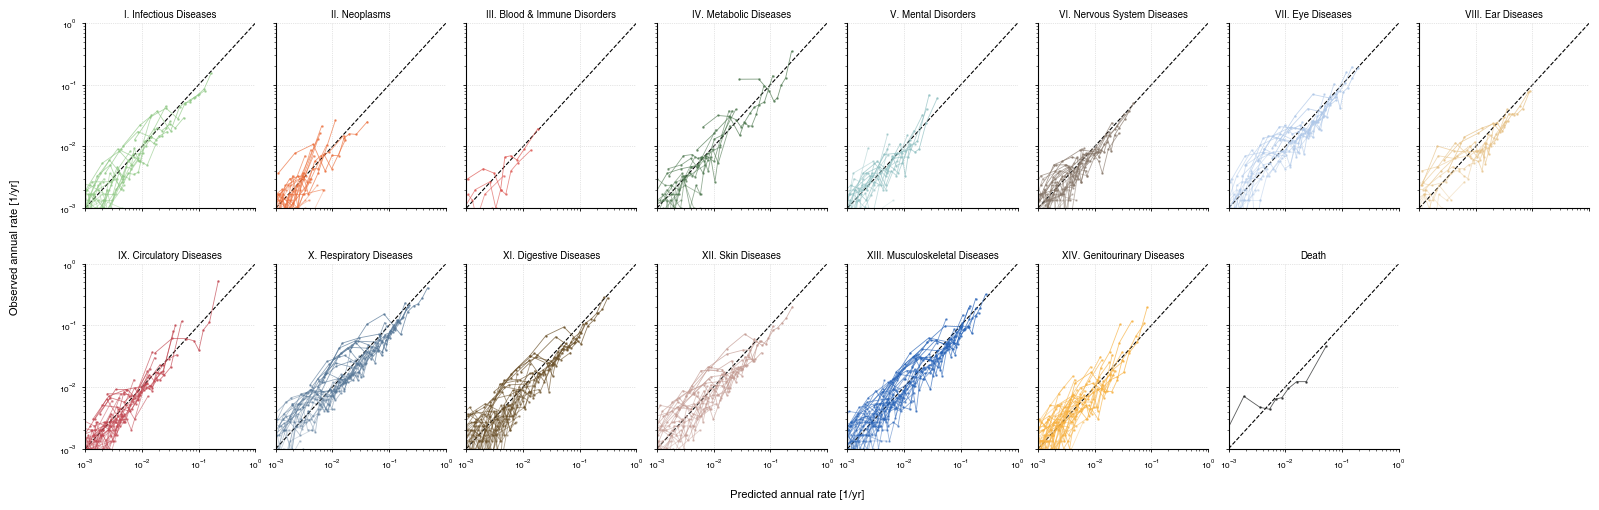

total disease lines drawn (raw): 559


,chapter,n_diseases,raw_pred_over_obs,calibrated_pred_over_obs
0,I. Infectious Diseases,42,2.802,0.973
1,II. Neoplasms,48,2.249,0.898
2,III. Blood & Immune Disorders,7,2.730,1.100
3,IV. Metabolic Diseases,28,3.353,1.086
4,V. Mental Disorders,26,2.139,0.919
5,VI. Nervous System Diseases,37,2.344,1.037
6,VII. Eye Diseases,35,2.936,0.934
7,VIII. Ear Diseases,17,2.330,0.986
8,IX. Circulatory Diseases,50,2.812,0.998
9,X. Respiratory Diseases,41,2.783,0.974


In [9]:
# === Figure 3g — per-disease log-log rate calibration by chapter (Delphi Fig.3b style) ===
from matplotlib.colors import to_rgba

# --- 이 그림 전용: 더 많은 환자 + 낮은 min_cases 로 밀도 높은 재평가 (cal 은 그대로 둠) ---
GRID_MIN_CASES = 8        # cal(=25) 보다 낮춰 더 많은 disease token 포함
GRID_N_PATIENTS = None    # None → val/test 겹치는 환자 전체 사용
# 관측 rate 바닥(decile bin floor ≈ 1/bin_size ≈ 3e-4/yr) 위로 하한을 올려 아래쪽 끊김 숨김.
# x·y 같은 범위로 두어 대각선 45° 유지. 필요시 x 하한을 1e-5로 낮춰 raw 저-rate tail 표시 가능.
GRID_RATE_XLIM = (1e-3, 1.0)
GRID_RATE_YLIM = (1e-3, 1.0)
GRID_N_BINS = min(N_BINS, 10)
GRID_MIN_POINTS = 2
GRID_SEED = 0
# fill_between 밴드: chapter 내 질환 곡선들을 공통 log x-grid에 보간 후 분위수 envelope 을 색칠
GRID_BAND_ENABLE = False   # fill_between 밴드 끔
# 밴드 = 질환 곡선들의 중앙 분위수(IQR류) 포락선을 gaussian 으로 부드럽게. 분포를 타이트하게 따라감.
GRID_BAND_PCTL = (5, 95)      # 밴드 하/상 분위수(%): 5~95=대부분 포함(경계 넓게)
GRID_BAND_MIN_DISEASES = 3    # 밴드를 그릴 최소 질환 수
GRID_BAND_GRID_POINTS = 80    # 보간 x-grid 점 수(많을수록 부드러움)
GRID_BAND_SIGMA = 6.0         # 밴드 경계 log-space gaussian smoothing 표준편차(클수록 매끈)
GRID_BAND_MARGIN = 0.10       # 추가 log10 여백 (경계 여유 넓게)
GRID_BAND_ALPHA = 0.20        # 밴드 투명도

if ("cal_grid" not in globals()) or (getattr(cal_grid, "min_cases", None) != GRID_MIN_CASES) \
        or (getattr(cal_grid, "_grid_n_patients", None) != GRID_N_PATIENTS):
    cal_grid = CalibrationAnalyzer(
        model,
        val_data=hist_raw, val_p2i=hist_p2i,
        test_data=fut_raw, test_p2i=fut_p2i,
        labels_path=str(LABELS_CHAPTER_PATH),
        device=DEVICE,
        apply_token_shift=APPLY_TOKEN_SHIFT,
        min_cases=GRID_MIN_CASES,
    )
    cal_grid.run(
        n_patients=(10 ** 9 if GRID_N_PATIENTS is None else GRID_N_PATIENTS),
        block_size=BLOCK_SIZE, eval_years=EVAL_YEARS,
    )
    cal_grid._grid_n_patients = GRID_N_PATIENTS

grid_token_meta = token_meta_table(cal_grid)

DISEASE_CHAPTER_ORDER = [
    "I. Infectious Diseases",
    "II. Neoplasms",
    "III. Blood & Immune Disorders",
    "IV. Metabolic Diseases",
    "V. Mental Disorders",
    "VI. Nervous System Diseases",
    "VII. Eye Diseases",
    "VIII. Ear Diseases",
    "IX. Circulatory Diseases",
    "X. Respiratory Diseases",
    "XI. Digestive Diseases",
    "XII. Skin Diseases",
    "XIII. Musculoskeletal Diseases",
    "XIV. Genitourinary Diseases",
    "Death",
]


def _prob_to_annual_rate(probability, years):
    p = np.clip(np.asarray(probability, dtype=float), 0.0, 1.0 - 1e-8)
    return -np.log1p(-p) / float(years)


def _build_raw_curves(patient_idx):
    """질환별 decile reliability → approximate annual (model_rate, observed_rate) 곡선."""
    curves = {ch: [] for ch in DISEASE_CHAPTER_ORDER}
    for token_id, row in grid_token_meta.iterrows():
        chapter = row["chapter"]
        if chapter not in DISEASE_CHAPTER_ORDER:
            continue
        pred_prob = np.asarray(cal_grid.pred_rates[patient_idx, int(token_id)], dtype=float)
        observed = np.asarray(cal_grid.observed[patient_idx, int(token_id)], dtype=float)
        mean_pred, obs_freq, count = reliability_curve(pred_prob, observed, GRID_N_BINS, "quantile")
        model_rate = _prob_to_annual_rate(mean_pred, EVAL_YEARS)
        observed_rate = _prob_to_annual_rate(obs_freq, EVAL_YEARS)
        valid = np.isfinite(model_rate) & np.isfinite(observed_rate) & (model_rate > 0) & (observed_rate > 0)
        if valid.sum() < GRID_MIN_POINTS:
            continue
        curves[chapter].append({
            "token_id": int(token_id),
            "name": row["name"],
            "color": row["color"],
            "n_cases": int(observed.sum()),
            "model_rate": model_rate[valid],
            "observed_rate": observed_rate[valid],
            "bin_count": count[valid],
        })
    return curves


# 환자 절반: fit 절반에서 보정을 적합, eval 절반에만 적용 (누수 방지)
grid_rng = np.random.default_rng(GRID_SEED)
grid_perm = grid_rng.permutation(cal_grid.pred_rates.shape[0])
grid_fit_idx = grid_perm[: len(grid_perm) // 2]
grid_eval_idx = grid_perm[len(grid_perm) // 2:]

fit_curves = _build_raw_curves(grid_fit_idx)
raw_eval_curves = _build_raw_curves(grid_eval_idx)

# (1) 전역 log-log 기울기: log10(obs) ~ b0 + b1*log10(model), bin 표본수 가중
_x_fit = np.concatenate([np.log10(c["model_rate"]) for cv in fit_curves.values() for c in cv])
_y_fit = np.concatenate([np.log10(c["observed_rate"]) for cv in fit_curves.values() for c in cv])
_w_fit = np.concatenate([c["bin_count"] for cv in fit_curves.values() for c in cv]).astype(float)
GRID_CAL_SLOPE, GRID_CAL_INTERCEPT = np.polyfit(_x_fit, _y_fit, 1, w=np.sqrt(_w_fit))


def _slope_map(model_rate):
    r = np.clip(np.asarray(model_rate, dtype=float), 1e-12, None)
    return np.power(10.0, GRID_CAL_INTERCEPT + GRID_CAL_SLOPE * np.log10(r))


# (2) 질환별 잔차 레벨 offset (fit 절반에서 기울기 교정 후 남는 로그평균 차이)
grid_disease_offset = {}
for cv in fit_curves.values():
    for c in cv:
        base = _slope_map(c["model_rate"])
        grid_disease_offset[c["token_id"]] = float(
            np.exp(np.mean(np.log(c["observed_rate"])) - np.mean(np.log(base)))
        )

print(
    f"grid: tokens~{sum(len(v) for v in raw_eval_curves.values())}, eval patients={len(grid_eval_idx):,}, "
    f"slope={GRID_CAL_SLOPE:.3f}, intercept={GRID_CAL_INTERCEPT:.3f}, "
    f"per-disease offsets={len(grid_disease_offset)}"
)


def _recalibrate(curve):
    base = _slope_map(curve["model_rate"])
    offset = grid_disease_offset.get(curve["token_id"], 1.0)
    return np.clip(base * offset, 1e-6, 5.0)


calibrated_eval_curves = {ch: [] for ch in DISEASE_CHAPTER_ORDER}
for chapter, curves in raw_eval_curves.items():
    for c in curves:
        cc = dict(c)
        cc["model_rate"] = _recalibrate(c)
        calibrated_eval_curves[chapter].append(cc)

disease_curves = {"raw": raw_eval_curves, "calibrated": calibrated_eval_curves}


def _gauss_smooth(values, sigma):
    """1D log-space 배열을 gaussian 커널로 부드럽게 (edge padding). 톱니 제거용."""
    values = np.asarray(values, dtype=float)
    if sigma <= 0 or values.size < 3:
        return values
    radius = max(1, int(round(3.0 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-(offsets ** 2) / (2.0 * sigma ** 2))
    kernel /= kernel.sum()
    padded = np.pad(values, radius, mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def _chapter_band(curves, xlo, xhi):
    """chapter 질환 곡선들을 공통 log x-grid 에 보간해 중앙 분위수(IQR류) 밴드를 구하고
    gaussian 으로 부드럽게 만든 (xgrid, lo, hi) 반환. 곡선 분포를 타이트하게 따라간다."""
    if len(curves) < GRID_BAND_MIN_DISEASES:
        return None
    xgrid = np.logspace(np.log10(xlo), np.log10(xhi), GRID_BAND_GRID_POINTS)
    log_xgrid = np.log10(xgrid)
    stacked = np.full((len(curves), xgrid.size), np.nan)
    for i, curve in enumerate(curves):
        mr = np.asarray(curve["model_rate"], dtype=float)
        orr = np.asarray(curve["observed_rate"], dtype=float)
        order = np.argsort(mr)
        lmr, lorr = np.log10(mr[order]), np.log10(orr[order])
        # 각 질환의 관측 x-범위 안에서만 보간(밖은 nan → 분위수에서 제외)
        inside = (log_xgrid >= lmr[0]) & (log_xgrid <= lmr[-1])
        if inside.sum() == 0:
            continue
        stacked[i, inside] = np.interp(log_xgrid[inside], lmr, lorr)
    count = np.sum(~np.isnan(stacked), axis=0)
    valid = count >= max(2, GRID_BAND_MIN_DISEASES - 1)
    if valid.sum() < 3:
        return None
    lo = np.nanpercentile(stacked, GRID_BAND_PCTL[0], axis=0)
    hi = np.nanpercentile(stacked, GRID_BAND_PCTL[1], axis=0)
    # 연속 유효 구간으로 자르고 내부 nan 은 보간
    idx = np.where(valid)[0]
    sl = slice(idx[0], idx[-1] + 1)
    xg, lo, hi = log_xgrid[sl], lo[sl], hi[sl]

    def _fill_nan(a):
        m = np.isnan(a)
        if m.any() and (~m).sum() >= 2:
            a = a.copy()
            a[m] = np.interp(xg[m], xg[~m], a[~m])
        return a

    lo, hi = _fill_nan(lo), _fill_nan(hi)
    # gaussian smoothing 으로 톱니 제거 (경계 broaden 없이 분위수 밴드 자체를 부드럽게)
    lo = _gauss_smooth(lo, GRID_BAND_SIGMA)
    hi = _gauss_smooth(hi, GRID_BAND_SIGMA)
    if GRID_BAND_MARGIN > 0:
        lo, hi = lo - GRID_BAND_MARGIN, hi + GRID_BAND_MARGIN
    return np.power(10.0, xg), np.power(10.0, lo), np.power(10.0, hi)


def _draw_disease_grid(stage, panel_label):
    fig, axes = plt.subplots(2, 8, figsize=(16.0, 5.6), sharex=True, sharey=True)
    axes = axes.ravel()
    xlo, xhi = GRID_RATE_XLIM
    ylo, yhi = GRID_RATE_YLIM
    diag_lo, diag_hi = min(xlo, ylo), max(xhi, yhi)
    for panel_idx, chapter in enumerate(DISEASE_CHAPTER_ORDER):
        ax = axes[panel_idx]
        curves = sorted(disease_curves[stage][chapter], key=lambda x: x["n_cases"])
        if GRID_BAND_ENABLE and curves:
            band = _chapter_band(curves, xlo, xhi)
            if band is not None:
                bx, blo, bhi = band
                band_color = curves[-1]["color"]
                ax.fill_between(bx, blo, bhi, color=to_rgba(band_color, alpha=GRID_BAND_ALPHA),
                                lw=0, zorder=1.5)
        for curve_idx, curve in enumerate(curves):
            strength = (curve_idx + 1) / max(len(curves), 1)
            ax.plot(
                curve["model_rate"], curve["observed_rate"],
                marker=".", markersize=1.6, lw=0.6,
                color=to_rgba(curve["color"], alpha=0.18 + 0.55 * strength), zorder=2,
            )
        ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi], "--", color="black", lw=0.8, zorder=1)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
        ax.grid(axis="both", which="major", color="0.80", ls=":", lw=0.5)
        ax.set_title(f"{chapter}", fontsize=7.0, fontweight="bold", pad=4)
        ax.tick_params(axis="both", which="major", labelsize=6, length=2.5, width=0.6)
        ax.tick_params(axis="both", which="minor", length=1.5, width=0.4)
        ax.label_outer()
    for ax in axes[len(DISEASE_CHAPTER_ORDER):]:
        ax.axis("off")
    # fig.text(0.008, 0.985, panel_label, ha="left", va="top", fontsize=11, fontweight="bold")
    fig.text(0.5, 0.052, "Predicted annual rate [1/yr]", ha="center", fontsize=8)
    fig.text(0.008, 0.5, "Observed annual rate [1/yr]", va="center", rotation="vertical", fontsize=8)
    # fig.text(
    #     0.5, 0.006,
    #     "Annual rate = -ln(1 - p) / T with T = 3 yr  "
    #     "(constant-hazard approximation of the 3-yr cumulative probability p)",
    #     ha="center", va="bottom", fontsize=6, style="italic", color="0.4",
    # )
    fig.subplots_adjust(left=0.055, right=0.995, bottom=0.14, top=0.90, wspace=0.12, hspace=0.30)
    return fig


fig_after = _draw_disease_grid(
    "calibrated",
    f"b2  After (slope {GRID_CAL_SLOPE:.2f} + per-disease offset)",
)
# fig_after.suptitle(
#     "Per-disease calibration by ICD chapter — after recalibration "
#     f"(global slope={GRID_CAL_SLOPE:.2f} + per-disease level offset)",
#     y=0.98, fontsize=11,
# )
if SAVE_FIGS:
    fig_after.savefig(OUTPUT_DIR / "calibration_disease_by_chapter_loglog_recalibrated.png", dpi=300, bbox_inches="tight")
plt.show()

disease_grid_rows = []
for chapter in DISEASE_CHAPTER_ORDER:
    row = {"chapter": chapter, "n_diseases": len(disease_curves["raw"][chapter])}
    for stage in ("raw", "calibrated"):
        curves = disease_curves[stage][chapter]
        if curves:
            mr = np.concatenate([c["model_rate"] for c in curves])
            orr = np.concatenate([c["observed_rate"] for c in curves])
            row[f"{stage}_pred_over_obs"] = float(np.exp(np.mean(np.log(mr)) - np.mean(np.log(orr))))
        else:
            row[f"{stage}_pred_over_obs"] = np.nan
    disease_grid_rows.append(row)
disease_grid_summary = pd.DataFrame(disease_grid_rows)
print(f"total disease lines drawn (raw): {int(disease_grid_summary['n_diseases'].sum())}")
if SAVE_FIGS:
    disease_grid_summary.to_csv(OUTPUT_DIR / "calibration_disease_by_chapter_loglog_summary.csv", index=False)
disease_grid_summary.round(3)
